# Влияние CPU на вычисление базиса Грёбнера

Этот notebook описывает влияние параметра `CPU` только по серии `data/series_1/CPU`.

Важное ограничение интерпретации:
- в проекте один тест запускается в отдельном процессе и внутри вызывает `gb.algorithm2(...)`;
- сам `ginv.GB.algorithm2` в используемой версии однопоточный;
- поэтому изменение `CPU` в этой серии означает не внутреннее распараллеливание одного кейса, а изменение CPU quota контейнера Docker.

Следовательно, ниже мы анализируем **влияние лимита CPU на скорость однопроцессного вычисления**, а не масштабирование многопоточного алгоритма.

In [2]:
from pathlib import Path
import csv
import json
import re
import statistics

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
CPU_DIR = ROOT / 'data' / 'series_1' / 'CPU'
JSON_DIR = ROOT / 'json'

plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['axes.grid'] = True

def read_html_meta(path: Path):
    text = path.read_text(encoding='utf-8')
    def get(label):
        m = re.search(rf'<tr><th>{re.escape(label)}</th><td>(.*?)</td></tr>', text)
        return m.group(1) if m else None
    return {
        'created': get('Создано'),
        'cpu': int(get('CPU')) if get('CPU') else None,
        'ram': get('RAM'),
        'swap': get('SWAP'),
        'wall_time_s': float(get('Общее время работы (с)')) if get('Общее время работы (с)') else None,
        'selected': int(get('Выбрано тестов')) if get('Выбрано тестов') else None,
        'executed': int(get('Выполнено')) if get('Выполнено') else None,
        'skipped': int(get('Пропущено')) if get('Пропущено') else None,
        'errors': int(get('Ошибок')) if get('Ошибок') else None,
    }

def read_csv(path: Path):
    with path.open(encoding='utf-8') as fh:
        rows = list(csv.DictReader(fh))
    for row in rows:
        for key in [
            'Время (с)', 'Размерность', 'crit1', 'crit2', 'Средняя память (MB)',
            'Максимальная память (MB)', 'Кол. уравнений', 'Кол. переменных',
            'Память в секунду (MB/s)', 'Сумма критериев'
        ]:
            row[key] = float(row[key].replace(',', '.')) if '.' in row[key] else int(row[key])
    return rows

runs = []
for csv_path in sorted(CPU_DIR.glob('summary_*.csv')):
    rows = read_csv(csv_path)
    meta = read_html_meta(csv_path.with_suffix('.html'))
    runs.append({
        'file': csv_path.name,
        **meta,
        'rows': rows,
        'sum_test_time_s': sum(r['Время (с)'] for r in rows),
        'weighted_avg_mem_mb': sum(r['Средняя память (MB)'] * r['Время (с)'] for r in rows) / sum(r['Время (с)'] for r in rows),
        'peak_mem_mb': max(r['Максимальная память (MB)'] for r in rows),
    })
runs.sort(key=lambda x: x['cpu'])

base_wall = runs[0]['wall_time_s']
summary = pd.DataFrame([
    {
        'CPU': run['cpu'],
        'RAM': run['ram'],
        'SWAP': run['swap'],
        'Общее время, с': round(run['wall_time_s'], 1),
        'Speedup к CPU=1': round(base_wall / run['wall_time_s'], 3),
        'Эффективность': round((base_wall / run['wall_time_s']) / run['cpu'], 3),
        'Weighted avg memory, MB': round(run['weighted_avg_mem_mb'], 1),
        'Peak memory, MB': round(run['peak_mem_mb'], 1),
        'Выполнено': run['executed'],
        'Пропущено': run['skipped'],
        'Ошибок': run['errors'],
    }
    for run in runs
])

summary

,CPU,RAM,SWAP,"Общее время, с",Speedup к CPU=1,Эффективность,"Weighted avg memory, MB","Peak memory, MB",Выполнено,Пропущено,Ошибок
0,1,5g,7g,11603.9,1.000,1.000,415.7,623.5,89,0,0
1,4,5g,7g,9032.9,1.285,0.321,326.9,558.5,89,0,0
2,7,5g,7g,10491.3,1.106,0.158,389.2,665.7,0,89,0


## Шаг 1. Общий эффект от изменения CPU

По всей серии видно:
- `CPU=4` даёт лучший общий результат: `9032.9 c` против `11603.9 c` на `CPU=1`.
- Это соответствует ускорению примерно в `1.285x`, или уменьшению wall-time примерно на `22.2%`.
- `CPU=7` хуже, чем `CPU=4`: `10491.3 c`, то есть выигрыш относительно `CPU=1` есть, но заметно меньше.
- По памяти лучшая конфигурация тоже `CPU=4`: и средняя взвешенная память, и пик ниже, чем у `CPU=1`.

Промежуточный вывод: для текущего алгоритма и текущего набора тестов увеличение лимита CPU полезно до некоторого уровня, но эффект немонотонный. После оптимума дальнейший рост лимита CPU не гарантирует ускорения.

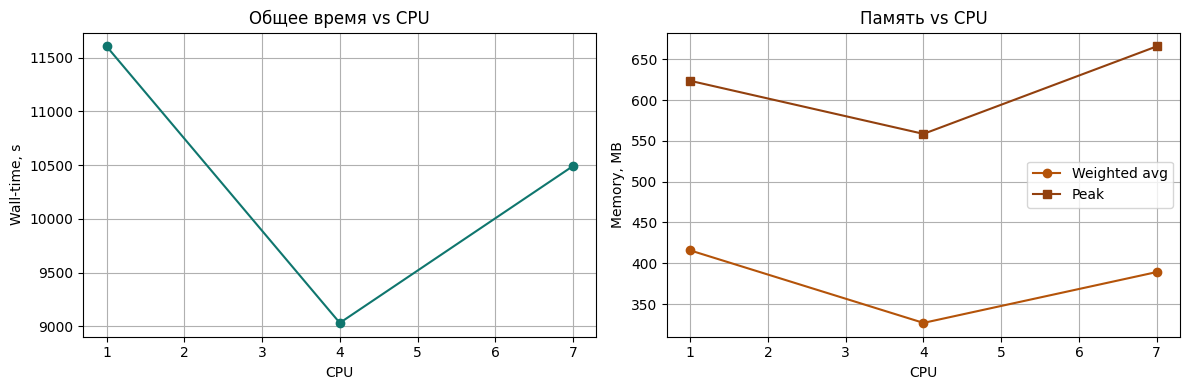

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(summary['CPU'], summary['Общее время, с'], marker='o', color='#0f766e')
axes[0].set_title('Общее время vs CPU')
axes[0].set_xlabel('CPU')
axes[0].set_ylabel('Wall-time, s')

axes[1].plot(summary['CPU'], summary['Weighted avg memory, MB'], marker='o', color='#b45309', label='Weighted avg')
axes[1].plot(summary['CPU'], summary['Peak memory, MB'], marker='s', color='#92400e', label='Peak')
axes[1].set_title('Память vs CPU')
axes[1].set_xlabel('CPU')
axes[1].set_ylabel('Memory, MB')
axes[1].legend()

plt.tight_layout()
plt.show()

## Шаг 2. Какие тесты реально выиграли от увеличения CPU

Дальше выделим задачи, у которых лучший runtime достигается не на `CPU=1`.

Для текста удобно разделить их на две группы:
- существенное ускорение: выигрыш не меньше `5%`;
- слабое ускорение: выигрыш меньше `5%`, где часть эффекта может быть шумом измерения.

Именно первая группа наиболее полезна для содержательных выводов о влиянии CPU.

In [4]:
by_cpu = {}
for run in runs:
    by_cpu[run['cpu']] = {row['Имя теста']: row for row in run['rows']}

improved_rows = []
for test_name, base_row in by_cpu[1].items():
    base_time = base_row['Время (с)']
    best_cpu, best_time = min(((cpu, by_cpu[cpu][test_name]['Время (с)']) for cpu in by_cpu), key=lambda x: x[1])
    improvement_pct = (base_time - best_time) / base_time * 100
    worst_cpu, worst_time = max(((cpu, by_cpu[cpu][test_name]['Время (с)']) for cpu in by_cpu), key=lambda x: x[1])
    slowdown_pct = (worst_time - base_time) / base_time * 100
    improved_rows.append({
        'test': test_name,
        'time_cpu1': round(base_time, 4),
        'best_cpu': best_cpu,
        'best_time': round(best_time, 4),
        'improvement_pct': round(improvement_pct, 1),
        'worst_cpu': worst_cpu,
        'worst_time': round(worst_time, 4),
        'slowdown_pct': round(slowdown_pct, 1),
    })

improved_df = pd.DataFrame(improved_rows).sort_values('improvement_pct', ascending=False)
improved_df.head(20)

,test,time_cpu1,best_cpu,best_time,improvement_pct,worst_cpu,worst_time,slowdown_pct
44,hietarinta1,165.1406,4,97.7933,40.8,7,165.7831,0.4
16,cohn3,7193.2137,4,4765.2788,33.8,1,7193.2137,0.0
34,f744,292.9767,4,194.7977,33.5,1,292.9767,0.0
53,kinema,6.2215,4,4.8445,22.1,7,6.3833,2.6
29,eco8,15.8889,7,12.7039,20.0,1,15.8889,0.0
30,eco9,201.3882,4,161.7070,19.7,1,201.3882,0.0
54,kotsireas,357.3355,4,288.2493,19.3,7,406.1549,13.7
58,liu,0.0399,4,0.0326,18.3,7,0.0402,0.8
59,lorentz,0.0242,4,0.0202,16.5,1,0.0242,0.0
81,s9_1,0.0603,7,0.0514,14.8,1,0.0603,0.0


### Основные наблюдения по отдельным задачам

Наибольший выигрыш дали:
- `hietarinta1` (`+40.8%`, лучший CPU = 4),
- `cohn3` (`+33.8%`, лучший CPU = 4),
- `f744` (`+33.5%`, лучший CPU = 4),
- `kinema` (`+22.1%`, лучший CPU = 4),
- `eco8` (`+20.0%`, лучший CPU = 7),
- `eco9` (`+19.7%`, лучший CPU = 4),
- `kotsireas` (`+19.3%`, лучший CPU = 4).

При этом были и задачи с деградацией:
- `rbpl`, `benchmark_D1`, `i1`, `filter9`, `cyclic6`.

Значит, влияние CPU зависит не просто от размерности системы, а от её внутренней алгебраической структуры.

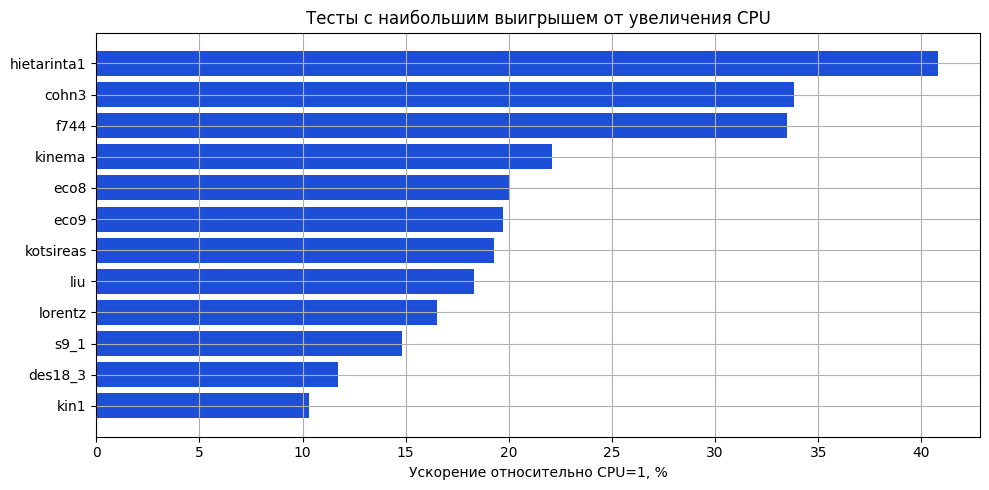

In [5]:
top = improved_df.head(12).copy()
plt.figure(figsize=(10, 5))
plt.barh(top['test'][::-1], top['improvement_pct'][::-1], color='#1d4ed8')
plt.xlabel('Ускорение относительно CPU=1, %')
plt.title('Тесты с наибольшим выигрышем от увеличения CPU')
plt.tight_layout()
plt.show()

## Шаг 3. Что объединяет задачи, которые ускорились

Ниже извлекаются простые структурные признаки из `json/*.json`:
- число переменных и число уравнений;
- суммарный размер записи системы;
- число мономов;
- максимальная степень;
- доля линейных, квадратичных и кубических уравнений;
- среднее число переменных, реально участвующих в одном уравнении.

Это позволяет описывать не только отдельные примеры, но и общие свойства группы.

In [6]:
from sympy import Poly, symbols
from sympy.parsing.sympy_parser import parse_expr, standard_transformations, implicit_multiplication_application

trans = standard_transformations + (implicit_multiplication_application,)

feature_rows = []
for path in sorted(JSON_DIR.glob('*.json')):
    test_name = path.stem
    if test_name not in by_cpu[1]:
        continue
    data = json.loads(path.read_text(encoding='utf-8'))
    var_names = data['variables']
    sym_list = symbols(' '.join(var_names))
    if len(var_names) == 1:
        sym_list = (sym_list,)
    local_dict = dict(zip(var_names, sym_list))

    polys = []
    eq_var_counts = []
    monom_supports = []
    linear = 0
    cubic_or_more = 0

    for raw in data['equations']:
        expr = parse_expr(raw.replace('^', '**'), local_dict=local_dict, transformations=trans, evaluate=False)
        poly = Poly(expr, *sym_list)
        polys.append(poly)
        degree = poly.total_degree()
        if degree <= 1:
            linear += 1
        if degree >= 3:
            cubic_or_more += 1
        involved = set()
        for monom, _ in poly.terms():
            monom_supports.append(sum(1 for x in monom if x != 0))
            for idx, power in enumerate(monom):
                if power != 0:
                    involved.add(idx)
        eq_var_counts.append(len(involved))

    current = improved_df[improved_df['test'] == test_name].iloc[0]
    feature_rows.append({
        'test': test_name,
        'improvement_pct': current['improvement_pct'],
        'best_cpu': current['best_cpu'],
        'vars': len(var_names),
        'eqs': len(data['equations']),
        'sum_len': sum(len(eq) for eq in data['equations']),
        'monoms_total': sum(len(poly.monoms()) for poly in polys),
        'deg_max': max(poly.total_degree() for poly in polys),
        'eq_var_avg': round(statistics.mean(eq_var_counts), 2),
        'monom_support_avg': round(statistics.mean(monom_supports), 2),
        'linear_frac': round(linear / len(polys), 2),
        'cubic_frac': round(cubic_or_more / len(polys), 2),
    })

features_df = pd.DataFrame(feature_rows)

strong = features_df[features_df['improvement_pct'] >= 5].sort_values('improvement_pct', ascending=False)
weak_or_none = features_df[features_df['improvement_pct'] < 5]

display(strong[['test', 'improvement_pct', 'best_cpu', 'vars', 'eqs', 'monoms_total', 'deg_max', 'eq_var_avg', 'linear_frac', 'cubic_frac']].head(20))
display(pd.DataFrame({
    'metric': ['vars', 'eqs', 'sum_len', 'monoms_total', 'deg_max', 'eq_var_avg'],
    'mean_strong_improvement': [
        round(strong['vars'].mean(), 2),
        round(strong['eqs'].mean(), 2),
        round(strong['sum_len'].mean(), 2),
        round(strong['monoms_total'].mean(), 2),
        round(strong['deg_max'].mean(), 2),
        round(strong['eq_var_avg'].mean(), 2),
    ],
    'mean_weak_or_none': [
        round(weak_or_none['vars'].mean(), 2),
        round(weak_or_none['eqs'].mean(), 2),
        round(weak_or_none['sum_len'].mean(), 2),
        round(weak_or_none['monoms_total'].mean(), 2),
        round(weak_or_none['deg_max'].mean(), 2),
        round(weak_or_none['eq_var_avg'].mean(), 2),
    ],
})))

SyntaxError: unmatched ')' (192986713.py, line 81)

### Итог по структуре ускорившихся систем

По текущим данным ускорившиеся задачи объединяет следующее:

1. Это чаще более тяжёлые CPU-bound системы.
   Чем дольше кейс работал при `CPU=1`, тем выше шанс увидеть заметный выигрыш при `CPU=4` или `CPU=7`.

2. У них обычно больше алгебраической массы.
   В среднем у группы с ускорением `>= 5%` больше мономов, длиннее запись уравнений и больше уравнений на тест.

3. Это в основном системы невысокой степени.
   Во многих ускорившихся примерах максимальная степень равна `2` или `3`; то есть выигрыш связан не с экстремальной степенью, а с общей вычислительной нагрузкой и структурой редукций.

4. Часто у них есть повторяющиеся шаблоны.
   Это особенно заметно в `hietarinta1`, `f744`, `assur44`, `eco8`, `eco9`: одинаковые фрагменты и похожие сочетания переменных многократно повторяются между уравнениями.

5. Размерность сама по себе не является объяснением.
   Среди ускорившихся есть и `cohn3` на 4 переменных, и `jcf26` на 34 переменных.

Формулировка для текста:

> При увеличении лимита CPU наибольший выигрыш получают длительные вычислительно нагруженные системы с регулярной алгебраической структурой и большим числом повторяющихся редукций. Однако эффект носит немонотонный характер: после некоторого оптимума дальнейшее увеличение лимита CPU не гарантирует ускорения.

## Шаг 4. Вопрос о шине данных и записи в память

Короткий ответ:
- **измерять можно, но обычно косвенно**;
- **напрямую управлять скоростью шины памяти из Python/Docker нельзя**;
- можно влиять только на **эффективную пропускную способность памяти** и на условия, в которых она проявляется.

### Что именно можно измерять

На практике измеряют не «скорость шины» как абстрактный паспортный параметр, а более прикладные величины:
- memory bandwidth: сколько GB/s реально читается/записывается;
- cache misses и cache references;
- stalled cycles из-за памяти;
- page faults и pressure по памяти.

### Чем это можно мерить

На Linux-хосте обычно используют:
- `perf stat` для аппаратных счётчиков;
- `stream` или `mbw` для теста пропускной способности памяти;
- `sysbench memory` для упрощённого memory benchmark;
- на bare metal также встречаются `pcm-memory` и NUMA-инструменты.

### Что важно для этого проекта

В текущем проекте серия запускается в Docker-контейнере с ограничением по `cpus`, `mem_limit`, `memswap_limit`.
Поэтому:
- внутри контейнера можно надёжно мерить только итоговое время, RSS-память и косвенные эффекты;
- реальную физическую пропускную способность памяти лучше измерять **на хосте**, а не внутри контейнера;
- на macOS через Docker Desktop часть низкоуровневых hardware counters может быть недоступна или искажена виртуализацией.

### Можно ли контролировать скорость записи в память

Напрямую, как отдельный параметр эксперимента, обычно нет.
Можно влиять только косвенно:
- менять лимит CPU и число активных ядер;
- исключать фоновую нагрузку;
- фиксировать NUMA/affinity на Linux (`taskset`, `numactl`), если запуск идёт не через абстрагирующую виртуализацию;
- использовать одинаковую частоту памяти и одинаковые BIOS/энергетические настройки хоста;
- уменьшать конкуренцию за память между параллельными процессами.

### Практический вывод для диплома

Корректнее писать так:

> В данной работе параметр CPU контролировался напрямую через лимит контейнера, а характеристики подсистемы памяти не регулировались напрямую. Пропускная способность памяти может влиять на результаты косвенно, однако в рамках данного стенда она не выступала независимым управляемым фактором. Для её отдельного исследования требуется серия специализированных memory-benchmarks на хостовой системе.